In [1]:
#import libraries

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import toolbelt as tb

In [2]:
rawDF = pd.read_csv("ev_vs_petrol_dataset_v3.csv")
rawDF.head()

,country,region,year,vehicle_segment,powertrain_type,ev_sales,petrol_car_sales,diesel_car_sales,total_vehicle_sales,ev_market_share,...,avg_ev_range_km,fuel_price_usd_per_liter,electricity_price_usd_per_kwh,gdp_per_capita,urban_population_percent,co2_emissions_transport_mt,ev_subsidy_usd,emission_regulation_score,ev_growth_rate_yoy,is_ev_dominant
0,Australia,Oceania,2010,commercial,ICE,5,92877,61921,154803,0.00,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
1,Australia,Oceania,2010,mass_market,ICE,57,535933,73089,609079,0.01,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
2,Australia,Oceania,2010,premium,ICE,37,235282,20462,255781,0.01,...,124,1.09,0.149,51977,88.8,88.7,0,30.4,0.00,0
3,Australia,Oceania,2011,commercial,ICE,11,98092,65395,163498,0.01,...,133,1.09,0.163,52807,88.9,88.3,0,30.8,120.00,0
4,Australia,Oceania,2011,mass_market,ICE,129,569679,77684,647492,0.02,...,133,1.09,0.163,52807,88.9,88.3,0,30.8,126.32,0


In [3]:
rawDF.describe()

,year,ev_sales,petrol_car_sales,diesel_car_sales,total_vehicle_sales,ev_market_share,charging_stations,fast_chargers_share,avg_ev_range_km,fuel_price_usd_per_liter,electricity_price_usd_per_kwh,gdp_per_capita,urban_population_percent,co2_emissions_transport_mt,ev_subsidy_usd,emission_regulation_score,ev_growth_rate_yoy,is_ev_dominant
count,1200.000000,1.200000e+03,1.200000e+03,1.200000e+03,1.200000e+03,1200.000000,1.200000e+03,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2017.500000,6.360236e+04,7.733063e+05,1.409369e+05,9.778455e+05,6.327992,5.693898e+04,14.437750,265.872500,1.342239,0.169508,35651.525000,74.609000,190.837000,2910.940000,58.761860,64.002958,0.018333
std,4.611694,4.079506e+05,1.756934e+06,2.913472e+05,2.211799e+06,13.231723,3.359383e+05,10.057529,121.994051,0.363461,0.079298,23899.013679,14.858811,363.100639,2477.306742,20.092871,71.386797,0.134210
min,2010.000000,5.000000e+00,1.727000e+03,1.500000e+02,1.748000e+04,0.000000,0.000000e+00,0.000000,106.000000,0.482900,0.066990,1359.000000,30.900000,5.400000,0.000000,19.484000,-40.960000,0.000000
25%,2013.750000,2.002500e+02,8.870500e+04,1.951075e+04,1.300465e+05,0.077500,4.917500e+02,6.000000,150.000000,1.097000,0.098750,11077.250000,64.175000,30.175000,0.000000,43.600000,16.372500,0.000000
50%,2017.500000,2.731500e+03,2.294785e+05,5.136100e+04,2.905130e+05,0.830000,4.090000e+03,12.900000,238.500000,1.352000,0.158000,37329.000000,79.900000,94.250000,2794.500000,59.350000,44.165000,0.000000
75%,2021.250000,1.990500e+04,6.385320e+05,1.111910e+05,7.624482e+05,5.832500,2.251800e+04,20.950000,380.250000,1.568500,0.220250,50930.000000,84.075000,159.575000,4973.750000,74.825000,80.907500,0.000000
max,2025.000000,7.670056e+06,1.477369e+07,2.014595e+06,1.884998e+07,95.000000,4.338106e+06,49.300000,507.000000,2.153000,0.379040,103437.000000,98.500000,1900.800000,8952.000000,95.602000,300.000000,1.000000


In [4]:
rawDF.isna().sum()

country                          0
region                           0
year                             0
vehicle_segment                  0
powertrain_type                  0
ev_sales                         0
petrol_car_sales                 0
diesel_car_sales                 0
total_vehicle_sales              0
ev_market_share                  0
charging_stations                0
fast_chargers_share              0
avg_ev_range_km                  0
fuel_price_usd_per_liter         0
electricity_price_usd_per_kwh    0
gdp_per_capita                   0
urban_population_percent         0
co2_emissions_transport_mt       0
ev_subsidy_usd                   0
emission_regulation_score        0
ev_growth_rate_yoy               0
is_ev_dominant                   0
dtype: int64

In [5]:
rawDF["country"].value_counts()

country
Australia         48
Netherlands       48
United Kingdom    48
Turkey            48
Thailand          48
Switzerland       48
Sweden            48
Spain             48
South Korea       48
Portugal          48
Poland            48
Norway            48
Mexico            48
Austria           48
Japan             48
Italy             48
Indonesia         48
India             48
Germany           48
France            48
China             48
Canada            48
Brazil            48
Belgium           48
United States     48
Name: count, dtype: int64

In [6]:
tb.getColumnsNumericalAndCategorical(rawDF)

"Categorical: ['country', 'region', 'vehicle_segment', 'powertrain_type'], Numerical: ['year', 'ev_sales', 'petrol_car_sales', 'diesel_car_sales', 'total_vehicle_sales', 'ev_market_share', 'charging_stations', 'fast_chargers_share', 'avg_ev_range_km', 'fuel_price_usd_per_liter', 'electricity_price_usd_per_kwh', 'gdp_per_capita', 'urban_population_percent', 'co2_emissions_transport_mt', 'ev_subsidy_usd', 'emission_regulation_score', 'ev_growth_rate_yoy', 'is_ev_dominant']"

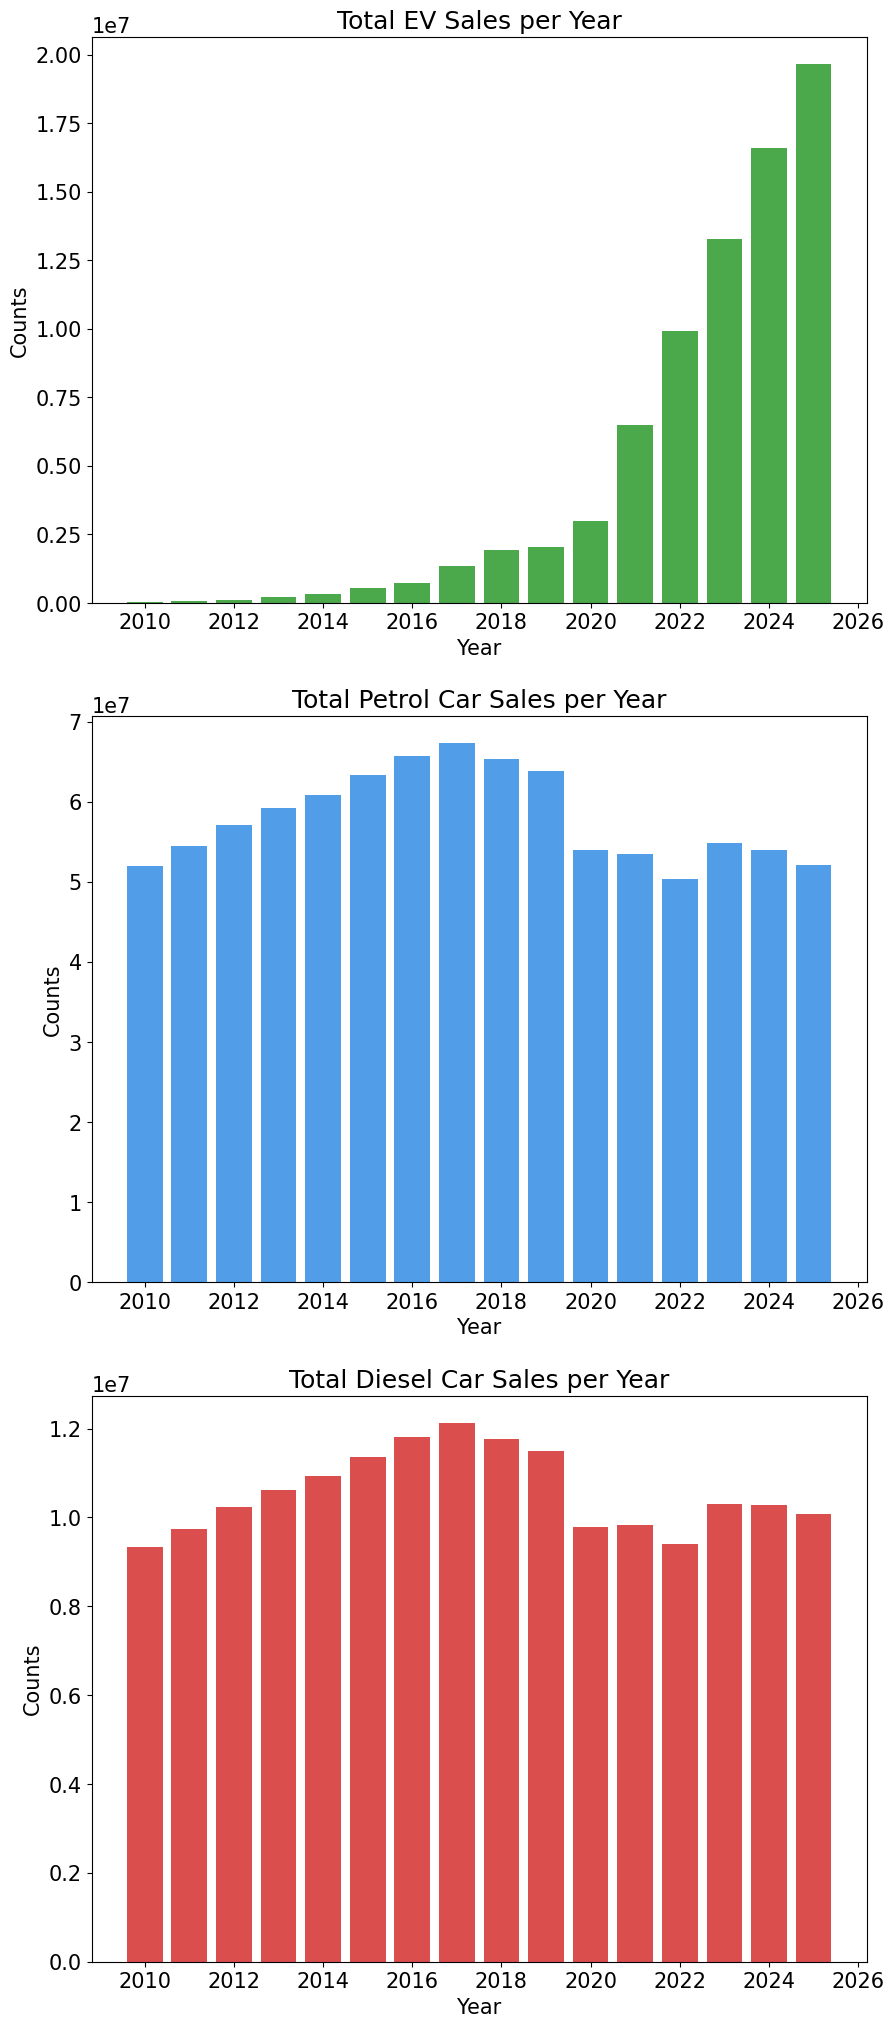

In [7]:
salesNumberList = ["ev_sales", "petrol_car_sales", "diesel_car_sales"]

salesTotals = rawDF.groupby("year")[salesNumberList].sum()

plt.rcParams["text.color"] = "black"
plt.rcParams["font.size"] = 15

fig, axs = plt.subplots(3, figsize=(10, 25))

axs[0].bar(salesTotals.index, salesTotals["ev_sales"], color = ["#4ba94b"])
axs[0].set_title("Total EV Sales per Year")
axs[0].set_xlabel("Year")
axs[0].set_ylabel("Counts")

axs[1].bar(salesTotals.index, salesTotals["petrol_car_sales"], color = ["#519de8"])
axs[1].set_title("Total Petrol Car Sales per Year")
axs[1].set_xlabel("Year")
axs[1].set_ylabel("Counts")

axs[2].bar(salesTotals.index, salesTotals["diesel_car_sales"], color = ["#db4e4e"])
axs[2].set_title("Total Diesel Car Sales per Year")
axs[2].set_xlabel("Year")
axs[2].set_ylabel("Counts")

plt.show()

Text(0.5, 1.0, 'Types of Cars Sold in 2025')

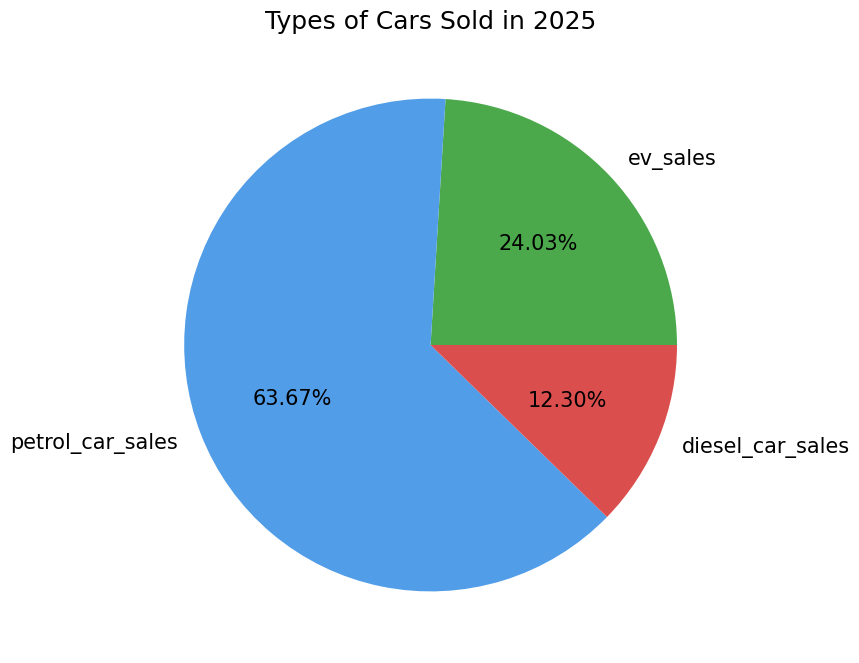

In [8]:
df_2025 = rawDF.copy()
df_2025 = df_2025[df_2025["year"] == 2025]
salesTotals_2025 = df_2025[salesNumberList].sum()

plt.figure(figsize=(8,8))
plt.pie(x=salesTotals_2025,
        labels = salesTotals_2025.index,
        autopct= '%1.2f%%',
        colors= ["#4ba94b", "#519de8", "#db4e4e"])
plt.title("Types of Cars Sold in 2025")


Text(0.5, 1.0, 'EV Market Share vs. GDP per Capita')

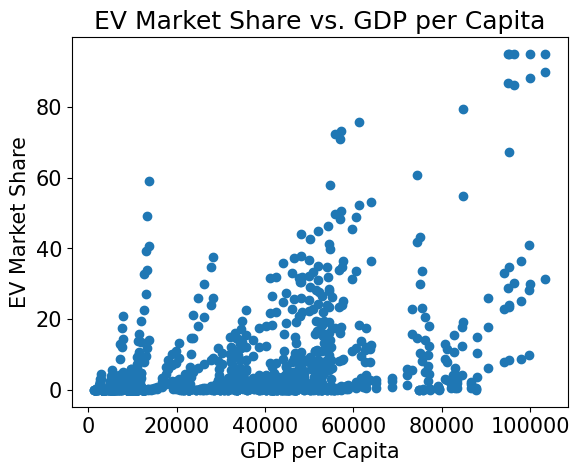

In [9]:
plt.scatter(x = rawDF["gdp_per_capita"],
            y = rawDF["ev_market_share"])
plt.xlabel("GDP per Capita")
plt.ylabel("EV Market Share")
plt.title("EV Market Share vs. GDP per Capita")

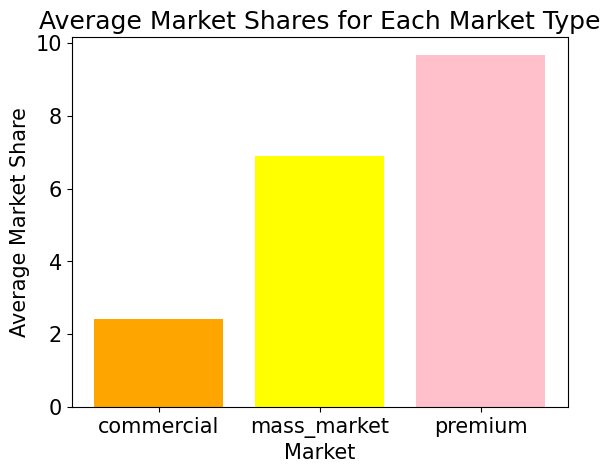

In [10]:
marketTypes = rawDF.groupby("vehicle_segment")["ev_market_share"].mean()

plt.bar(marketTypes.index, marketTypes, color = ["orange", "yellow", "pink"])
plt.title("Average Market Shares for Each Market Type")
plt.xlabel("Market")
plt.ylabel("Average Market Share")
plt.show()

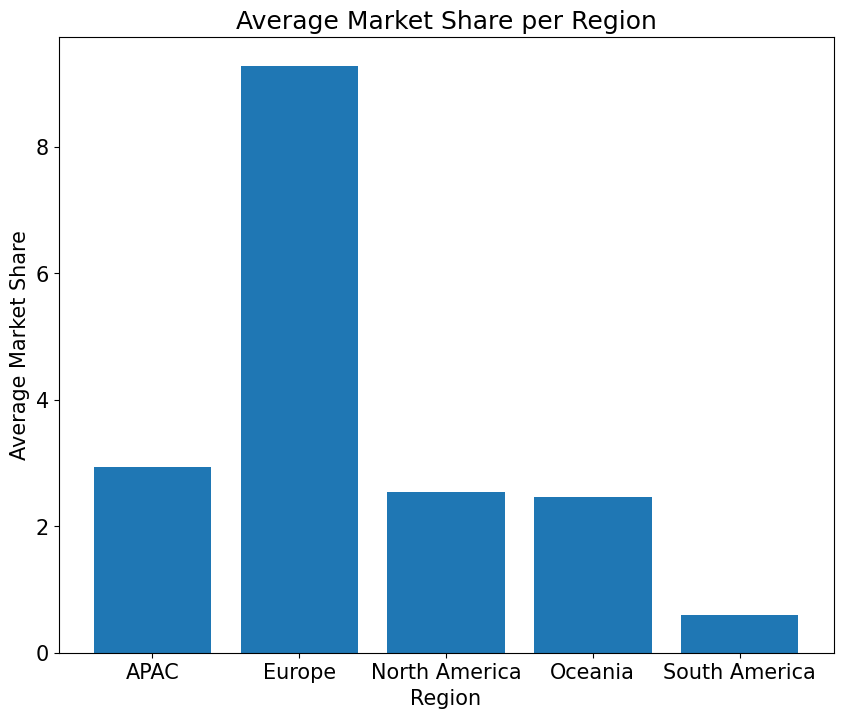

In [11]:
averageMarketShare = rawDF.groupby("region")["ev_market_share"].mean()
plt.figure(figsize=(10,8))
plt.bar(averageMarketShare.index, averageMarketShare)
plt.title("Average Market Share per Region")
plt.xlabel("Region")
plt.ylabel("Average Market Share")
plt.show()

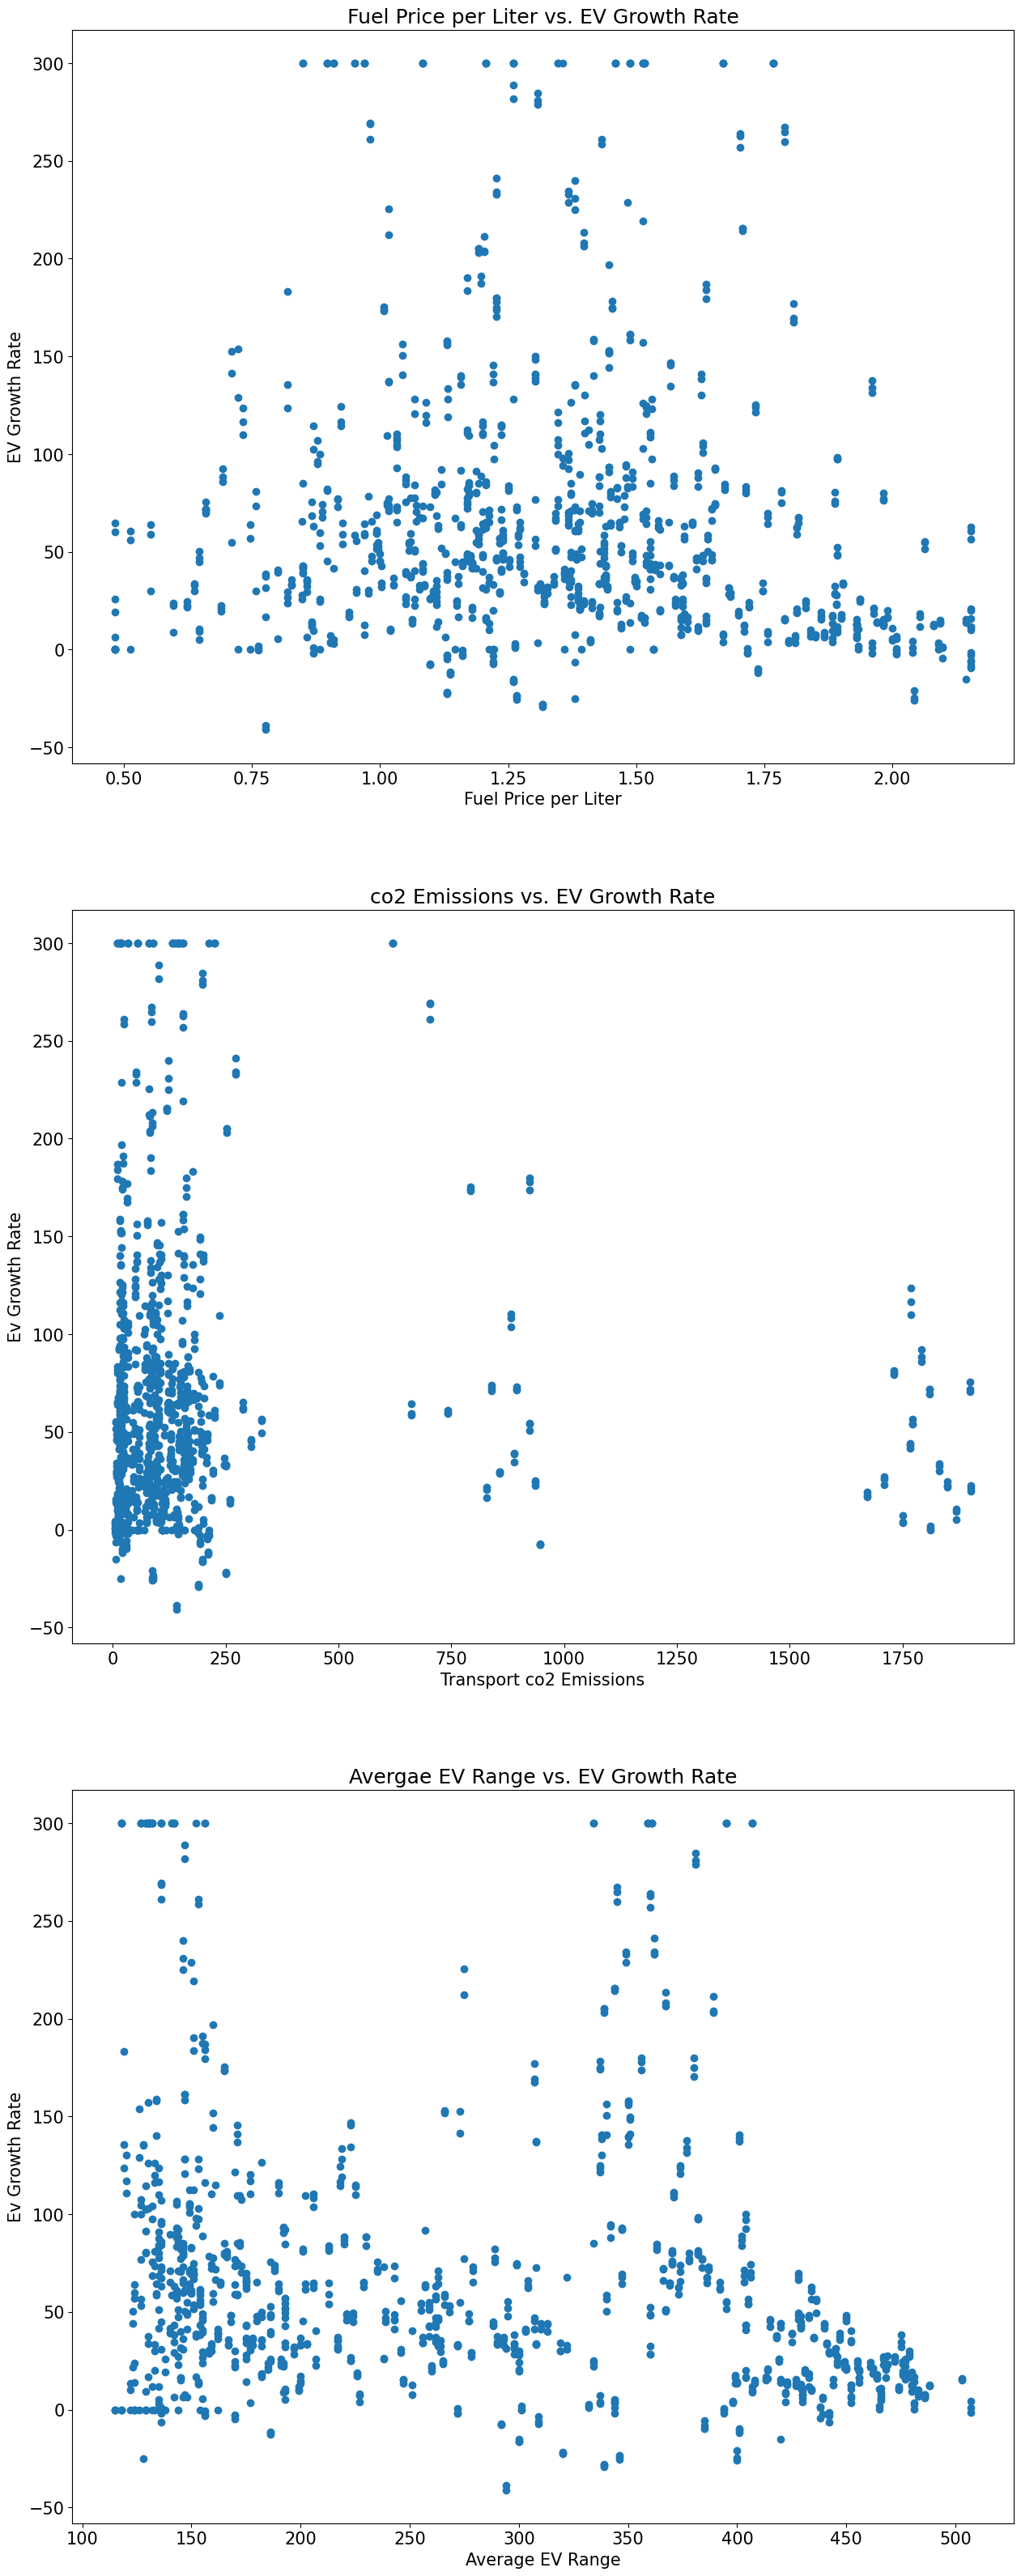

In [12]:
not_2010_DF = rawDF.copy()
not_2010_DF = not_2010_DF[not_2010_DF["year"] != 2010]

fig, axs = plt.subplots(3, figsize=(15, 40))

axs[0].scatter(x = not_2010_DF["fuel_price_usd_per_liter"],
               y = not_2010_DF["ev_growth_rate_yoy"])
axs[0].set_xlabel("Fuel Price per Liter")
axs[0].set_ylabel("EV Growth Rate")
axs[0].set_title("Fuel Price per Liter vs. EV Growth Rate")

axs[1].scatter(x = not_2010_DF["co2_emissions_transport_mt"],
               y = not_2010_DF["ev_growth_rate_yoy"])
axs[1].set_xlabel("Transport co2 Emissions")
axs[1].set_ylabel("Ev Growth Rate")
axs[1].set_title("co2 Emissions vs. EV Growth Rate")

axs[2].scatter(x = not_2010_DF["avg_ev_range_km"],
               y = not_2010_DF["ev_growth_rate_yoy"])
axs[2].set_xlabel("Average EV Range")
axs[2].set_ylabel("Ev Growth Rate")
axs[2].set_title("Avergae EV Range vs. EV Growth Rate")
plt.show()